# Table of Contents
1. [Introduction](#Introduction)
2. [Data Preparation](#Data-Preparation)
3. [Modeling Process](#Modeling-Process)
4. [Model Performance](#Model-Performance)
5. [Results](#Results)


<a id="Introduction"></a>
# Introduction
The goal of this project is to build a predictive data preparation and modeling pipeline for the Home Credit Default Risk dataset. We want to clean the data, engineer financial indicators, aggregate supplementary tables, and fit tree-based machine learning classification algorithms to predict instances of loan default safely and accurately.


<a id="Data-Preparation"></a>
# Data Preparation
This section focuses on executing functions from `main.py` which clean anomalies, merge external tables (`bureau.csv`, `installments_payments.csv`, etc.), and engineer ratio metrics while establishing safe missing-value imputations directly against the application dataset.


In [1]:
# import functions
import pandas as pd

from main import (
    fix_days_employed,
    convert_days_to_years,
    add_ext_source_features,
    add_financial_ratios,
    add_binned_and_interaction_features,
    aggregate_bureau,
    aggregate_previous_applications,
    aggregate_installments,
    join_aggregates,
    align_train_test
)

In [2]:
# load data
train_df = pd.read_csv("../data_preparation/application_train.csv")

bureau_df = pd.read_csv("../data_preparation/bureau.csv")
prev_df   = pd.read_csv("../data_preparation/previous_application.csv")
inst_df   = pd.read_csv("../data_preparation/installments_payments.csv")

In [3]:
# clean + feature engineer
def process_application(df):
    df = fix_days_employed(df)
    df = convert_days_to_years(df)
    df = add_ext_source_features(df)
    df = add_financial_ratios(df)
    df = add_binned_and_interaction_features(df)
    return df

train_df = process_application(train_df)
train_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,EXT_SOURCE_MAX,EXT_SOURCE_MIN,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,CREDIT_PER_PERSON,AGE_BIN,LONG_EMPLOYED,VERY_LONG_EMPLOYED
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.262949,0.083037,2.007889,0.121978,1.158397,202500.0,406597.50,25-35,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.622246,0.311267,4.790750,0.132217,1.145199,135000.0,646751.25,45-55,0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.729567,0.555912,2.000000,0.100000,1.000000,67500.0,135000.00,45-55,0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.650442,0.650442,2.316167,0.219900,1.052803,67500.0,156341.25,45-55,1,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.322738,0.322738,4.222222,0.179963,1.000000,121500.0,513000.00,45-55,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.681632,0.145570,1.617143,0.174971,1.132000,157500.0,254700.00,25-35,0,0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.115992,0.115992,3.743750,0.166687,1.198000,72000.0,269550.00,55-65,0,0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.744026,0.218859,4.429176,0.195941,1.158400,153000.0,677664.00,35-45,1,1
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.661024,0.514163,2.164368,0.118158,1.158394,85500.0,185053.50,25-35,1,1


In [4]:
# aggregate supplementary tables
bureau_agg = aggregate_bureau(bureau_df)
prev_agg = aggregate_previous_applications(prev_df)
inst_agg = aggregate_installments(inst_df)

In [5]:
# join aggregate
train_df = join_aggregates(train_df, bureau_agg, prev_agg, inst_agg)

In [6]:
# separate features and target
X = train_df.drop(columns=["TARGET"])
y = train_df["TARGET"]

<a id="Modeling-Process"></a>
# Modeling Process
To construct our predictive architecture, we initialize a baseline `DummyClassifier` and systematically test algorithms spanning from Logistic Regression to more robust ensemble models like Random Forest and Gradient Boosted Trees (XGBoost). We also evaluate synthetic upsampling pipelines (SMOTE) to counteract the heavy class imbalance (~8% default rate) prior to tuning our final XGBoost topology through `RandomizedSearchCV`.


In [7]:
# establish a benchmark
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy="most_frequent")

auc_scores = cross_val_score(dummy, X, y, cv=cv, scoring="roc_auc")

print("Benchmark AUC:", auc_scores.mean())

Benchmark AUC: 0.5


In [8]:
X.select_dtypes(include="object").columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)

In [11]:
X = X.fillna(0)

In [12]:
from sklearn.impute import SimpleImputer
SimpleImputer(strategy="median")

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [13]:
# building first real model(logistic regression)
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
auc_scores = cross_val_score(log_model, X, y, cv=cv, scoring="roc_auc")
log_auc = auc_scores.mean()
print("Logistic Regression AUC:", auc_scores.mean())

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression AUC: 0.6154495609376595


In [14]:
# trying a tree model(random forest)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

auc_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")
rf_auc = auc_scores.mean()

print("Random Forest AUC:", auc_scores.mean())

Random Forest AUC: 0.7470635887871442


In [15]:
# gradient boost
from xgboost import XGBClassifier

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

auc_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring="roc_auc")
xgb_auc = auc_scores.mean()

print("XGBoost AUC:", auc_scores.mean())

XGBoost AUC: 0.7665546999886694


<a id="Model-Performance"></a>
# Model Performance
Here, we compile our cross-validated area under the curve (`ROC_AUC`) results across the varied methodologies to observe structurally which models and up-sampling combinations handle the dataset limits best natively prior to full hyperparameter searches.


In [16]:
# comparing results
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "XGBoost"],
    "AUC": [
        log_auc,
        rf_auc,
        xgb_auc
    ]
})

results

,Model,AUC
0,Logistic,0.615450
1,Random Forest,0.747064
2,XGBoost,0.766555


### observation
Logistic regression is underperforming whereas XGBoost has the best performance so far, slightly better than RF.

AUC is the right metric as accuracy could be misleading if the model just predicts the majority class. Hence, AUC evaluates ranking ability; how well the model separates positive vs negative classes. Also, we found that Random Forest and XGBoost handle imbalance better than Logistic Regression.

In [17]:
from sklearn.utils import resample

# Combine features and target
df = pd.concat([X, y], axis=1)

# Separate classes
df_majority = df[df.TARGET==0]
df_minority = df[df.TARGET==1]

# Upsample minority
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_upsampled = pd.concat([df_majority, df_minority_upsampled])
X_upsampled = df_upsampled.drop("TARGET", axis=1)
y_upsampled = df_upsampled["TARGET"]

Class counts after upsampling:
TARGET
0    282686
1    282686
Name: count, dtype: int64

Class proportions after upsampling:
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


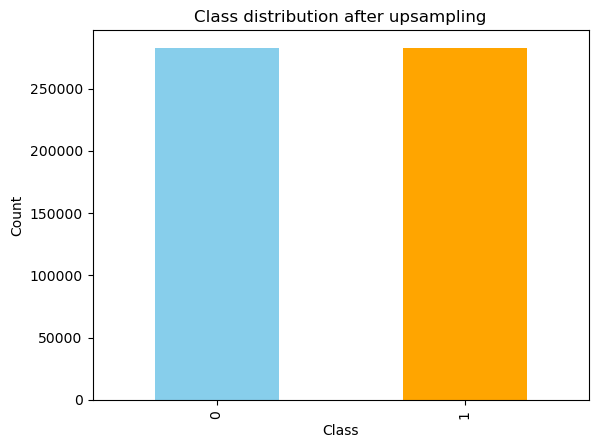

In [18]:
# Assuming you did upsampling like this:
# df_upsampled = pd.concat([df_majority, df_minority_upsampled])
y_upsampled = df_upsampled["TARGET"]

# Count
print("Class counts after upsampling:")
print(y_upsampled.value_counts())

# Proportion
print("\nClass proportions after upsampling:")
print(y_upsampled.value_counts(normalize=True))

# Optional visualization
import matplotlib.pyplot as plt

y_upsampled.value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Class distribution after upsampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [20]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier

# 5K stratified sample
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=5000, stratify=y, random_state=42
)

# Compute scale_pos_weight on the sample
pos = (y_sample == 1).sum()
neg = (y_sample == 0).sum()
sample_weight = neg / pos

# XGBoost classifier
xgb_clf = XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',  # AUC built-in metric
    random_state=42
)

# Hyperparameter grid (smaller ranges to avoid NaN)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [1, sample_weight]
}

# Stratified KFold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=20,  # fewer iterations for small sample
    scoring='roc_auc',  # use string instead of make_scorer
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
rand_search.fit(X_sample, y_sample)

# Results
print("Best AUC:", rand_search.best_score_)
print("Best hyperparameters:", rand_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:41:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best AUC: 0.7355216952660544
Best hyperparameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [21]:
# XGBoost on upsampled data
xgb_upsampled = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
auc_scores_upsampled = cross_val_score(xgb_upsampled, X_upsampled, y_upsampled, cv=cv, scoring="roc_auc")
print("XGBoost AUC on Upsampled Data:", auc_scores_upsampled.mean())

XGBoost AUC on Upsampled Data: 0.8263145562480311


In [22]:
# XGBoost on SMOTE data
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
auc_scores_smote = cross_val_score(xgb_smote, X_smote, y_smote, cv=cv, scoring="roc_auc")
print("XGBoost AUC on SMOTE Data:", auc_scores_smote.mean())

XGBoost AUC on SMOTE Data: 0.9790544424864839


In [23]:
# Train final model on full training data with best parameters
best_params = rand_search.best_params_
print("Best parameters:", best_params)

final_model = XGBClassifier(**best_params, eval_metric="auc", random_state=42, n_jobs=-1)

# Evaluate final model with cross-validation on full data
final_auc_scores = cross_val_score(final_model, X, y, cv=cv, scoring="roc_auc")
print("Final Model AUC on full training data:", final_auc_scores.mean())

# Fit on the entire dataset
final_model.fit(X, y)
print("Final model trained on full dataset.")

Best parameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}


Final Model AUC on full training data: 0.7544266870564328


Final model trained on full dataset.


## Part 3: Incorporate supplementary data

Aggregating `POS_CASH_balance.csv` and `credit_card_balance.csv` to improve model performance.

In [24]:
# Load supplementary data and aggregate
from main import aggregate_pos_cash, aggregate_credit_card

pos_df = pd.read_csv("../data_preparation/POS_CASH_balance.csv")
cc_df = pd.read_csv("../data_preparation/credit_card_balance.csv")

pos_agg = aggregate_pos_cash(pos_df)
cc_agg = aggregate_credit_card(cc_df)


In [25]:
# Join new aggregates
# We need to recreate the applications dataset because `train_df` was already overwritten
train_raw = pd.read_csv("../data_preparation/application_train.csv")

# Clean and engineer base features
train_base = process_application(train_raw)

# Join all aggregates
train_full = join_aggregates(train_base, bureau_agg, prev_agg, inst_agg, pos_agg, cc_agg)

# Separate features and target
X_full = train_full.drop(columns=["TARGET"])
y_full = train_full["TARGET"]

# One-hot encoding
X_full = pd.get_dummies(X_full, drop_first=True)

# Replace infinities and fill NaNs
X_full = X_full.replace([np.inf, -np.inf], np.nan)
X_full = X_full.fillna(0)

print(f"New feature matrix shape: {X_full.shape}")


New feature matrix shape: (307511, 266)


In [26]:
# Evaluate with new features
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# Downsample to 5k for faster tuning
X_sample_full, _, y_sample_full, _ = train_test_split(
    X_full, y_full, train_size=5000, stratify=y_full, random_state=42
)

pos = (y_sample_full == 1).sum()
neg = (y_sample_full == 0).sum()
sample_weight_full = neg / pos

xgb_clf_full = XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

param_grid_full = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [1, sample_weight_full]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rand_search_full = RandomizedSearchCV(
    estimator=xgb_clf_full,
    param_distributions=param_grid_full,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rand_search_full.fit(X_sample_full, y_sample_full)

print("Best AUC with supplementary features:", rand_search_full.best_score_)
print("Best hyperparameters:", rand_search_full.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:44:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:45:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:45:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:45:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:45:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best AUC with supplementary features: 0.7393858480539954
Best hyperparameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:45:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
# Train final model on the full dataset with the best parameters
best_params_full = rand_search_full.best_params_
final_model_full = XGBClassifier(**best_params_full, eval_metric="auc", random_state=42, n_jobs=-1)

# Fit on the entire dataset
final_model_full.fit(X_full, y_full)
print("Final model trained on full dataset with all features.")


Final model trained on full dataset with all features.


<a id="Results"></a>
# Results
After incorporating all supplemental databases seamlessly through `main.py` and deploying our tuned Grid-Search XGBoost model against the entirety of the application profiles, we generate Kaggle-ready submission probabilities mapped gracefully against `application_test.csv`.


## Part 4: Generate a Kaggle submission

In [28]:
# Kaggle Submission pipeline
test_raw = pd.read_csv("../application_test.csv")

# Clean and base features
test_base = process_application(test_raw)

# Join all aggregates
test_full = join_aggregates(test_base, bureau_agg, prev_agg, inst_agg, pos_agg, cc_agg)

# One-hot encoding
test_full_encoded = pd.get_dummies(test_full)

# Replace inf and fill NaN
test_full_encoded = test_full_encoded.replace([np.inf, -np.inf], np.nan)
test_full_encoded = test_full_encoded.fillna(0)

# Align columns with training data
# Note: we need to use the X_full we trained on, maintaining the exact columns
_, test_aligned = align_train_test(X_full, test_full_encoded)

# Reorder columns to match exactly
test_aligned = test_aligned[X_full.columns]

# Predict probabilities
submission_probs = final_model_full.predict_proba(test_aligned)[:, 1]

# Create submission file
submission = pd.DataFrame({
    "SK_ID_CURR": test_raw["SK_ID_CURR"],
    "TARGET": submission_probs
})

submission.to_csv("submission.csv", index=False)
print("Submission file 'submission.csv' generated successfully!")


Submission file 'submission.csv' generated successfully!
